### Train

#### 一、整体流程
加载数据集-->划分训练集/验证集-->初始化模型、优化器、损失函数-->循环多轮训练+验证-->保存最优模型

#### 二、数据处理函数
作用：准备训练和验证用的数据
1. 准备数据集合
2. 数据预处理：transforms.Compose尺寸统一(trasnsform.Resize(size = ))+转为张量(transform.ToTensor())
3. 拆分数据集：8：2
4. 封装为数据加载器: batch_size,shuffle(打乱)num_worke(线程)

In [1]:
import time
import copy 
import torch 
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
import torch.nn as nn
import torch.utils.data as Data
import matplotlib.pyplot as plt
from model import LeNet
import pandas as pd

In [2]:
def train_val_data_process():
  train_data = FashionMNIST(root='./data',
                            train=True,
                            transform=transforms.Compose([transforms.Resize(size=28),transforms.ToTensor()]),
                            download = True)
  train_data, val_data = Data.random_split(train_data, [round(0.8*len(train_data)), round(0.2*len(train_data))])
  train_dataloder = Data.DataLoader(dataset = train_data,
                                    batch_size =32,
                                    shuffle = True,
                                    num_workers=2)
  val_dataloder = Data.DataLoader(dataset = val_data,
                                  batch_size =32, 
                                  shuffle = True,
                                  num_workers=2)
  return train_dataloder,val_dataloder
                          
                          
                          

#### 三、模型训练函数
作用：训练+验证模型，保存最优参数
1. 训练前初始化：设备；优化器；损失函数；复制初始模型参数；初始化记录变量
2. 多轮循环训练
   1. 训练集训练：
      1. 切换训练模式
      2. 遍历每一批数据
      3. 前向传播：Pre_lab = torch.argmax(output,dim = -1) 输入图像，模型输出预测结果
      4. 计算损失，预测正确数量
      5. 反向传播：梯度初始化optimizer.zero_grad()
      6. 累计本轮总损失、正确数
   2. 验证集训练
      1. 切换评估模式
      2. 遍历数据
      3. 前向传播计算预测、损失
      4. 累计本轮验证损失、正确数
      5. 不进行反向传播
   3. 每轮结束后
      1. 计算平均损失+准确率
      2. 打印训练/验证结果
      3. 保存最优模型
      4. 记录耗时
   4. 训练全部结束
      1. 保存最优模型
      2. 返回所有损失、准确率

In [ ]:
def train_model_process(model, train_dataloader,val_dataloader, num_epochs):
  # 设定训练所用到的设备，有GPU用GPU没有GPU用CPU
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  # 使用Adam优化器
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  # 使用交叉熵损失函数
  criterion = nn.CrossEntropyLoss()
  # 模型放到设备上
  model = model.to(device)
  # 复制当前模型参数
  best_model_wts = copy.deepcopy(model.state_dict())

  # 初始化参数
  best_acc = 0.0
  train_loss_all = []
  val_loss_all = []
  train_acc_all = []
  val_acc_all = []
  since = time.time()

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs - 1))
    print('-' * 10)

    # 初始化参数
    train_loss = 0.0
    val_loss = 0.0
    train_corrects = 0
    val_corrects = 0
    train_num = 0
    val_num = 0

    for step,(b_x,b_y) in enumerate(train_dataloader):
      # 将数据放到设备上
      b_x = b_x.to(device)
      b_y = b_y.to(device)
      model.train()
      # 前向传播
      output = model(b_x)
      pre_lab = torch.argmax(output,dim=1)
      loss = criterion(output, b_y)
      # 反向传播和优化
      optimizer.zero_grad() #梯度初始化
      loss.backward()
      optimizer.step() #根据网路哟反向传播的梯度信息来更新网络参数，降低loss函数计算值
      # 计算训练损失和准确率
      train_loss += loss.item() * b_x.size(0)
      # 如果预测正确，则准确度加1
      train_corrects += torch.sum(pre_lab == b_y.data)
      train_num += b_x.size(0)


    for step,(b_x,b_y) in enumerate(val_dataloader):
      # 将数据放到设备上
      b_x = b_x.to(device)
      b_y = b_y.to(device)
      model.eval()
      # 前向传播
      output = model(b_x)
      pre_lab = torch.argmax(output,dim=1)
      loss = criterion(output, b_y)
     
      # 计算验证损失和准确率
      val_loss += loss.item() * b_x.size(0)
      # 如果预测正确，则准确度加1
      val_corrects += torch.sum(pre_lab == b_y.data)
      val_num += b_x.size(0)
    
    # 计算并保存每一次迭代的loss值和准确率
    # 训练集的loss
    train_loss_all.append(train_loss / train_num)
    # 验证集的acc
    train_acc_all.append(train_corrects.double().item() / train_num)

    # 验证集的loss
    val_loss_all.append(val_loss / val_num)
    # 验证集的acc
    val_acc_all.append(val_corrects.double().item() / val_num)

    print("{} train loss:{:.4f} train acc: {:.4f}".format(epoch, train_loss_all[-1], train_acc_all[-1]))
    print("{} val loss:{:.4f} val acc: {:.4f}".format(epoch, val_loss_all[-1], val_acc_all[-1]))

    if val_acc_all[-1]>best_acc:
      #保存最高准确度
      best_acc = val_acc_all[-1]
      #保存当前最高准确度的模型参数
      best_model_wts = copy.deepcopy(model.state_dict())

    # 计算训练和验证的耗时
    time_use = time.time() - since
    print('Time use: {:.0f}m {:.0f}s'.format(time_use // 60, time_use % 60))
  
  torch.save(best_model_wts, "./best.pth")

  train_process = pd.DataFrame(data={"epoch":range(num_epochs),
                                       "train_loss_all":train_loss_all,
                                       "val_loss_all":val_loss_all,
                                       "train_acc_all":train_acc_all,
                                       "val_acc_all":val_acc_all,})
  
  return train_process



In [4]:
def matplot_acc_loss(train_process):
    # 显示每一次迭代后的训练集和验证集的损失函数和准确率
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_process['epoch'], train_process.train_loss_all, "ro-", label="Train loss")
    plt.plot(train_process['epoch'], train_process.val_loss_all, "bs-", label="Val loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.subplot(1, 2, 2)
    plt.plot(train_process['epoch'], train_process.train_acc_all, "ro-", label="Train acc")
    plt.plot(train_process['epoch'], train_process.val_acc_all, "bs-", label="Val acc")
    plt.xlabel("epoch")
    plt.ylabel("acc")
    plt.legend()
    plt.show()

Epoch 0/19
----------
0 train loss:1.1105 train acc: 0.5762
0 val loss:0.7349 val acc: 0.7280
Time use: 0m 13s
Epoch 1/19
----------
1 train loss:0.6471 train acc: 0.7485
1 val loss:0.6035 val acc: 0.7682
Time use: 0m 40s
Epoch 2/19
----------
2 train loss:0.5463 train acc: 0.7891
2 val loss:0.5175 val acc: 0.8057
Time use: 1m 6s
Epoch 3/19
----------
3 train loss:0.4910 train acc: 0.8135
3 val loss:0.4808 val acc: 0.8210
Time use: 1m 32s
Epoch 4/19
----------
4 train loss:0.4526 train acc: 0.8304
4 val loss:0.4559 val acc: 0.8360
Time use: 1m 60s
Epoch 5/19
----------
5 train loss:0.4283 train acc: 0.8410
5 val loss:0.4175 val acc: 0.8492
Time use: 2m 31s
Epoch 6/19
----------
6 train loss:0.4070 train acc: 0.8481
6 val loss:0.4081 val acc: 0.8471
Time use: 3m 1s
Epoch 7/19
----------
7 train loss:0.3919 train acc: 0.8528
7 val loss:0.4039 val acc: 0.8502
Time use: 3m 31s
Epoch 8/19
----------
8 train loss:0.3758 train acc: 0.8602
8 val loss:0.3965 val acc: 0.8513
Time use: 3m 60s
Epo

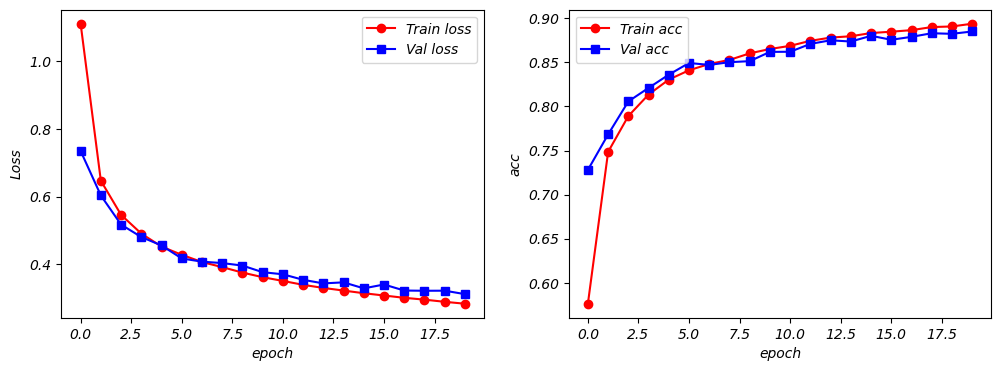

In [5]:
if __name__ == '__main__':
    # 加载需要的模型
    LeNet = LeNet()
    # 加载数据集
    train_data, val_data = train_val_data_process()
    # 利用现有的模型进行模型的训练
    train_process = train_model_process(LeNet, train_data, val_data, num_epochs=20)
    matplot_acc_loss(train_process)
